# EDA 03 - Data Integrity Engineering

Purpose:

- Verify that image files and labels are valid before deeper modeling.
- Find corrupt, blank, duplicate, extreme, or suspicious samples.
- Build compact candidate lists for manual inspection.

This notebook is intentionally forensic. It does not decide that a sample is definitely wrong; it surfaces rows that deserve human review.

## 0. Setup

Run this notebook from anywhere. It resolves paths relative to the project root.

In [2]:
import os
import re
import sys
import math
import json
import hashlib
import unicodedata
from pathlib import Path
from collections import Counter, defaultdict

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageStat
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.constants import (
    ID_COL,
    TARGET_COL,
    TRAIN_CSV,
    TEST_CSV,
    SAMPLE_SUBMISSION_CSV,
    TRAIN_MANIFEST,
    TEST_MANIFEST,
    IMAGE_DIR,
)
from src.common.text_normalization import normalize_text

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 80)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

REPORT_DIR = PROJECT_ROOT / "reports" / "data_integrity"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Report dir:   {REPORT_DIR}")

Matplotlib is building the font cache; this may take a moment.


Project root: /home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records
Report dir:   /home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/reports/data_integrity


In [3]:
paths = {
    "Train.csv": TRAIN_CSV,
    "Test.csv": TEST_CSV,
    "SampleSubmission.csv": SAMPLE_SUBMISSION_CSV,
    "train_manifest.csv": TRAIN_MANIFEST,
    "test_manifest.csv": TEST_MANIFEST,
    "images": IMAGE_DIR,
}
for name, path in paths.items():
    print(f"{name:>22}: exists={path.exists()} path={path}")

             Train.csv: exists=True path=/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/road-barbados-historic-handwriting-challenge/Train.csv
              Test.csv: exists=True path=/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/road-barbados-historic-handwriting-challenge/Test.csv
  SampleSubmission.csv: exists=True path=/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/road-barbados-historic-handwriting-challenge/SampleSubmission.csv
    train_manifest.csv: exists=True path=/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/metadata/train_manifest.csv
     test_manifest.csv: exists=True path=/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/metadata/test_manifest.cs

## 1. Load Tables And Basic Schema Checks

Checks:

- expected files exist;
- expected columns exist;
- row counts;
- train/test/sample ID consistency;
- duplicate IDs;
- missing labels.

In [4]:
train = pd.read_csv(TRAIN_CSV, encoding="utf-8-sig")
test = pd.read_csv(TEST_CSV, encoding="utf-8-sig")
sample = pd.read_csv(SAMPLE_SUBMISSION_CSV, encoding="utf-8-sig")
train_manifest = pd.read_csv(TRAIN_MANIFEST)
test_manifest = pd.read_csv(TEST_MANIFEST)

print("Raw CSV shapes")
print({
    "train": train.shape,
    "test": test.shape,
    "sample_submission": sample.shape,
    "train_manifest": train_manifest.shape,
    "test_manifest": test_manifest.shape,
})

for name, df in [("train", train), ("test", test), ("sample", sample)]:
    print(f"\n{name} columns: {df.columns.tolist()}")

Raw CSV shapes
{'train': (4098, 2), 'test': (1374, 1), 'sample_submission': (1374, 2), 'train_manifest': (4098, 11), 'test_manifest': (1374, 7)}

train columns: ['ID', 'Target']

test columns: ['ID']

sample columns: ['ID', 'Target']


In [5]:
def check_required_columns(df, required, name):
    missing = sorted(set(required) - set(df.columns))
    if missing:
        print(f"[FAIL] {name}: missing columns {missing}")
    else:
        print(f"[OK]   {name}: required columns present {required}")

check_required_columns(train, [ID_COL, TARGET_COL], "train")
check_required_columns(test, [ID_COL], "test")
check_required_columns(sample, [ID_COL, TARGET_COL], "sample")
check_required_columns(train_manifest, [ID_COL, TARGET_COL, "image_path", "fold"], "train_manifest")
check_required_columns(test_manifest, [ID_COL, "image_path"], "test_manifest")

print("\nID set checks")
print("test IDs == sample IDs:", set(test[ID_COL].astype(str)) == set(sample[ID_COL].astype(str)))
print("train/test overlap:", len(set(train[ID_COL].astype(str)) & set(test[ID_COL].astype(str))))

id_checks = []
for name, df in [("train", train), ("test", test), ("sample", sample), ("train_manifest", train_manifest), ("test_manifest", test_manifest)]:
    ids = df[ID_COL].astype(str)
    id_checks.append({
        "table": name,
        "rows": len(df),
        "unique_ids": ids.nunique(),
        "duplicate_id_rows": int(ids.duplicated(keep=False).sum()),
        "missing_id_rows": int(df[ID_COL].isna().sum()),
    })
pd.DataFrame(id_checks)

[OK]   train: required columns present ['ID', 'Target']
[OK]   test: required columns present ['ID']
[OK]   sample: required columns present ['ID', 'Target']
[OK]   train_manifest: required columns present ['ID', 'Target', 'image_path', 'fold']
[OK]   test_manifest: required columns present ['ID', 'image_path']

ID set checks
test IDs == sample IDs: True
train/test overlap: 0


,table,rows,unique_ids,duplicate_id_rows,missing_id_rows
0,train,4098,4098,0,0
1,test,1374,1374,0,0
2,sample,1374,1374,0,0
3,train_manifest,4098,4098,0,0
4,test_manifest,1374,1374,0,0


In [6]:
label_integrity = pd.DataFrame({
    "metric": [
        "train rows",
        "missing labels",
        "empty-after-normalize labels",
        "unique exact labels",
        "duplicated exact label rows",
    ],
    "value": [
        len(train),
        int(train[TARGET_COL].isna().sum()),
        int(train[TARGET_COL].map(normalize_text).eq("").sum()),
        int(train[TARGET_COL].astype(str).nunique()),
        int(train[TARGET_COL].astype(str).duplicated(keep=False).sum()),
    ],
})
label_integrity

,metric,value
0,train rows,4098
1,missing labels,0
2,empty-after-normalize labels,0
3,unique exact labels,4086
4,duplicated exact label rows,22


## 2. Image Readability, Hashes, And Quality Metrics

Checks:

- file exists;
- image is readable;
- exact file hash duplicates;
- average-hash near duplicates;
- blank or almost blank images;
- extreme brightness/contrast/sharpness;
- foreground touching image borders, which can indicate cropped handwriting.

In [7]:
def md5_file(path, chunk_size=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def average_hash(gray, size=8):
    small = gray.resize((size, size), Image.Resampling.BILINEAR)
    arr = np.asarray(small, dtype=np.float32)
    bits = arr > arr.mean()
    value = 0
    for bit in bits.ravel():
        value = (value << 1) | int(bit)
    return f"{value:0{size * size // 4}x}"


def image_quality_metrics(path):
    record = {
        "image_path": str(path),
        "exists": Path(path).exists(),
        "readable": False,
        "error": None,
    }
    if not record["exists"]:
        record["error"] = "missing_file"
        return record

    try:
        record["file_md5"] = md5_file(path)
        with Image.open(path) as image:
            image.load()
            record["readable"] = True
            record["mode"] = image.mode
            record["width"], record["height"] = image.size
            record["area"] = record["width"] * record["height"]
            record["aspect_ratio"] = record["width"] / max(record["height"], 1)
            gray = ImageOps.grayscale(image)
            arr = np.asarray(gray, dtype=np.float32)
            record["ahash"] = average_hash(gray)
            record["brightness_mean"] = float(arr.mean())
            record["brightness_median"] = float(np.median(arr))
            record["contrast_std"] = float(arr.std())
            record["p01"] = float(np.percentile(arr, 1))
            record["p99"] = float(np.percentile(arr, 99))
            record["dynamic_range_1_99"] = record["p99"] - record["p01"]
            record["dark_pixel_ratio"] = float((arr < 80).mean())
            record["bright_pixel_ratio"] = float((arr > 245).mean())
            record["foreground_ratio"] = float((arr < 245).mean())
            gy, gx = np.gradient(arr)
            record["sharpness_grad_var"] = float((gx ** 2 + gy ** 2).var())
            # Border ink ratios: high values can indicate cropped ascenders/descenders/strokes.
            border = max(2, int(round(min(arr.shape) * 0.05)))
            top = arr[:border, :]
            bottom = arr[-border:, :]
            left = arr[:, :border]
            right = arr[:, -border:]
            record["top_foreground_ratio"] = float((top < 220).mean())
            record["bottom_foreground_ratio"] = float((bottom < 220).mean())
            record["left_foreground_ratio"] = float((left < 220).mean())
            record["right_foreground_ratio"] = float((right < 220).mean())
    except Exception as exc:
        record["error"] = repr(exc)
    return record


def build_image_quality_table(train_manifest, test_manifest):
    image_rows = pd.concat([
        train_manifest[[ID_COL, "image_path"]].assign(split="train"),
        test_manifest[[ID_COL, "image_path"]].assign(split="test"),
    ], ignore_index=True)

    image_rows = image_rows.drop_duplicates(subset=[ID_COL, "image_path"]).reset_index(drop=True)
    
    records = []
    for row in image_rows.itertuples(index=False):
        record = image_quality_metrics(Path(row.image_path))
        record[ID_COL] = getattr(row, ID_COL)
        record["split"] = row.split
        records.append(record)
    return pd.DataFrame(records)

image_quality = build_image_quality_table(train_manifest, test_manifest)
image_quality.to_csv(REPORT_DIR / "image_quality_audit.csv", index=False)
print(f"Saved: {REPORT_DIR / 'image_quality_audit.csv'}")
image_quality.head()

Saved: /home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/reports/data_integrity/image_quality_audit.csv


,image_path,exists,readable,error,file_md5,mode,width,height,area,aspect_ratio,ahash,brightness_mean,brightness_median,contrast_std,p01,p99,dynamic_range_1_99,dark_pixel_ratio,bright_pixel_ratio,foreground_ratio,sharpness_grad_var,top_foreground_ratio,bottom_foreground_ratio,left_foreground_ratio,right_foreground_ratio,ID,split
0,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/uGI8F9Er0c5Xwd...,True,True,None,02989e6c7a87b70e8c4b9996a29568b2,RGB,1321,113,149273,11.690265,ffeff7f0e0001470,159.453308,169.0,29.795210,74.0,202.0,128.0,0.025544,0.00008,0.999846,1.799530e+05,0.985743,1.000000,0.821534,1.0,uGI8F9Er0c5XwdnX,train
1,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/Dqt2gc3V5RJqmL...,True,True,None,218eadbfa6f30e56c607d96bc39b6cde,RGB,1136,86,97696,13.209302,ffffffc70000c541,164.764603,179.0,36.681843,69.0,207.0,138.0,0.053759,0.00000,1.000000,2.128770e+05,1.000000,1.000000,1.000000,1.0,Dqt2gc3V5RJqmLE5,train
2,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/eqF93vAKYa4aOe...,True,True,None,a77ddad5c15218cc8e55fc29b4ef9fb7,RGB,885,49,43365,18.061224,fefcf0200000fefe,201.354523,213.0,31.470858,83.0,227.0,144.0,0.007172,0.00000,1.000000,1.644690e+06,0.742373,0.875141,0.867347,1.0,eqF93vAKYa4aOeHr,train
3,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/SEYEZ7fwp3MbYk...,True,True,None,8f5f45540a65afdc978d607169eb99bc,RGB,923,68,62764,13.573529,ffffff7b000020ff,206.805435,214.0,24.637194,93.0,225.0,132.0,0.003091,0.00000,1.000000,1.076330e+06,0.976526,0.966414,0.882353,1.0,SEYEZ7fwp3MbYkkB,train
4,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/sQjpjiUTThaMf4...,True,True,None,fe6d5611c48aedec2ca64ec9c7299874,RGB,859,49,42091,17.530612,fff0f0700001fffb,187.315369,198.0,30.058655,69.0,211.0,142.0,0.020171,0.00000,1.000000,1.239523e+06,0.999418,0.998836,1.000000,1.0,sQjpjiUTThaMf4j6,train


In [8]:
readability_summary = image_quality.groupby("split").agg(
    rows=(ID_COL, "count"),
    exists=("exists", "sum"),
    readable=("readable", "sum"),
    bad_images=("readable", lambda s: int((~s).sum())),
).reset_index()
readability_summary

,split,rows,exists,readable,bad_images
0,test,1374,1374,1374,0
1,train,4098,4098,4098,0


In [9]:
bad_images = image_quality[~image_quality["readable"] | ~image_quality["exists"]]
bad_images[["split", ID_COL, "image_path", "exists", "readable", "error"]]

,split,ID,image_path,exists,readable,error


## 3. Duplicate IDs, Labels, And Images

This section separates:

- duplicated IDs;
- duplicated exact labels;
- exact duplicate image files;
- near duplicate image appearance via average hash;
- duplicate image groups with conflicting labels.

In [10]:
train_targets = train[[ID_COL, TARGET_COL]].copy()
train_targets["normalized_target"] = train_targets[TARGET_COL].map(normalize_text)

print("Duplicate IDs")
for name, df in [("train", train), ("test", test), ("sample", sample)]:
    dup = df[df[ID_COL].astype(str).duplicated(keep=False)].copy()
    print(f"{name}: {len(dup)} duplicate ID rows")
    if len(dup):
        display(dup.sort_values(ID_COL).head(20))

exact_label_dups = (
    train_targets[train_targets["normalized_target"].duplicated(keep=False)]
    .sort_values("normalized_target")
    .reset_index(drop=True)
)
print(f"Exact duplicated label rows: {len(exact_label_dups)}")
exact_label_dups.head(30)

Duplicate IDs
train: 0 duplicate ID rows
test: 0 duplicate ID rows
sample: 0 duplicate ID rows
Exact duplicated label rows: 23


,ID,Target,normalized_target
0,eqF93vAKYa4aOeHr,By this public act and Instrument of protest be it known,By this public act and Instrument of protest be it known
1,SEYEZ7fwp3MbYkkB,By this public act and Instrument of protest be it known,By this public act and Instrument of protest be it known
2,uGI8F9Er0c5XwdnX,By this publique Act and Instrument of protest,By this publique Act and Instrument of protest
3,Dqt2gc3V5RJqmLE5,By this publique Act and Instrument of protest,By this publique Act and Instrument of protest
4,UUMGGElAnTqRKlfO,Sealed and delivered in the presence of,Sealed and delivered in the presence of
5,5fg6hZ3GqQbzwqGI,Sealed and delivered in the presence of,Sealed and delivered in the presence of
6,rmAMD7qwDT9Hnue7,Sealed and delivered in the presence of,Sealed and delivered in the presence of
7,BU7IrN4RM2C3UZC0,Sealed and delivered in the prsence of,Sealed and delivered in the prsence of
8,huKYbaDS0hn3iQSa,Sealed and delivered in the prsence of,Sealed and delivered in the prsence of
9,zF6Y0Q8CW0z7x0EU,Sealed and delivered in the prsence of,Sealed and delivered in the prsence of


In [11]:
train_quality = image_quality[image_quality["split"].eq("train")].merge(
    train_targets[[ID_COL, "normalized_target"]], on=ID_COL, how="left"
)

exact_file_dups = train_quality[train_quality["file_md5"].duplicated(keep=False)].copy()
if len(exact_file_dups):
    exact_summary = exact_file_dups.groupby("file_md5").agg(
        rows=(ID_COL, "count"),
        unique_labels=("normalized_target", "nunique"),
        ids=(ID_COL, lambda x: list(x)),
        labels=("normalized_target", lambda x: list(dict.fromkeys(x))),
    ).reset_index().sort_values(["unique_labels", "rows"], ascending=False)
else:
    exact_summary = pd.DataFrame(columns=["file_md5", "rows", "unique_labels", "ids", "labels"])

exact_summary.to_csv(REPORT_DIR / "exact_duplicate_image_groups.csv", index=False)
print(f"Exact duplicate image groups: {len(exact_summary)}")
exact_summary.head(20)

Exact duplicate image groups: 0


,file_md5,rows,unique_labels,ids,labels


In [12]:
ahash_dups = train_quality[train_quality["ahash"].duplicated(keep=False)].copy()
if len(ahash_dups):
    ahash_summary = ahash_dups.groupby("ahash").agg(
        rows=(ID_COL, "count"),
        unique_file_hashes=("file_md5", "nunique"),
        unique_labels=("normalized_target", "nunique"),
        ids=(ID_COL, lambda x: list(x)[:20]),
        labels=("normalized_target", lambda x: list(dict.fromkeys(x))[:20]),
    ).reset_index().sort_values(["unique_labels", "rows"], ascending=False)
else:
    ahash_summary = pd.DataFrame(columns=["ahash", "rows", "unique_file_hashes", "unique_labels", "ids", "labels"])

ahash_summary.to_csv(REPORT_DIR / "near_duplicate_ahash_groups.csv", index=False)
print(f"Near duplicate average-hash groups: {len(ahash_summary)}")
ahash_summary.head(20)

Near duplicate average-hash groups: 65


,ahash,rows,unique_file_hashes,unique_labels,ids,labels
52,ffffff000000ffff,27,27,27,"[JesQeqgmULF8vwiQ, j2LurOY7wQORapJ7, OJhRQ83sCjOmDnwA, 9WnZHqY88T78Cgvz, Ojj6uX95vgCZre1M, zmjkSQH1SVVb9fkA, WvRMZ0cyEWnKAntR, BlnVS9GQL...","[apptening unto him ye sd Benjamin Andrew his heires Exrs admrs or assignes for evr, wise appteyninge To have & to hould the sd Moyetie ..."
48,fffffd000000ffff,7,7,7,"[rp4H5pJTa7wJSk7A, 2YjzLWwIRjBQrfYJ, qrnDdzUyfIWC1P92, pcV8GSjK9kOqOJiG, uBxQjLV72cV5ZyOd, TNj9e2WZsERqMUIr, 9Qm9OusTY8YfwMZF]","[one Morgan Powell tenant in the sd lands together with all houses, bills of Sale mortgages or any other Imcumbrance whatsovr: and yt he..."
40,fffff7000000ffff,5,5,5,"[Do9613kZhc4ERTHH, IsoozHEv1bLiWAmk, 9LOWWZHYaqkxw9t5, m0y9JGPFARFAT1CF, TjTVl32ifA12hdCO]","[the other Moyetie or halfe pte of the sd sume of money, Jone Williams Fran: Lawrence & Margt: Lawrence equally to be divided, Ediffices..."
19,ffff3f000000ffff,4,4,4,"[eQQ3IQx58TBpuia3, Qkew66HYhHK6FUaR, aO980ubOx3cZVuRC, 4qNiElGdNamh3CJ3]","[right title & interest wch within this bill of Sale wch, hold stuffe & all other the aforesd prmisses wth the appurtenances, of the sai..."
20,ffff3f0000e0ffff,4,4,4,"[Df4U8pt1RP853mVW, x9BUUW3VkWBq4glW, 7npGfBUDtkUmpBlM, kZU5BU5Ai1LMfjnt]","[the said John Kempson Thomas Bond and Thomas Jones by severall daies and, the receipt Have Given bargained Sold & delivered and do by, ..."
36,fffff000001fffff,4,4,4,"[VVIZM5oForBFbyvQ, mWMqvmu5qzhPsCbC, XLgjgkCDuAhIw9Xn, LdOlQ8KSXjoYotv2]","[& that freed and cleered from all former sales mortgages dues avearages of dues & other incubrances, under his hand and seale beareing ..."
44,fffffb000000ffff,4,4,4,"[LDUIMQ5Q2O1e0itH, OPirApb1YBhVAi22, 6CgWci4yEyEkXbLS, 4T3KjmXjntlgbIM8]","[the draw of the said bill as alsoe against David Browning on whom, Knowe all all men by theis prsents that I James Percell, thereunto b..."
47,fffffc00000fffff,4,4,4,"[fnkzgge74EJdbXzH, hQteG5BVr6RHUkma, MLxbHPNerTkSoSoa, 5lZQwhSdHxFoHmJT]","[and sell unto the said George Milles twenty acres of land or there aboutes fallen, these presents binde my selfe unto ye above said Wil..."
49,fffffe000000ffff,4,4,4,"[QUi3QTPXo3RN2M7o, zu7WyNEAqHCGsLBk, 94t3dQgGikUWEkad, xC7aIldZbqIcAEuE]","[edifices and buildings upon ye said land erected -, together wth all pfitts hereunto belonginge The sd John Hunt, Ja: Ranton Eastwd Hew..."
57,ffffff020000ffff,4,4,4,"[gg5hfS9d6SHxZS3e, eA99xKMTmSaRiVOV, 5kTI5aWWhHnjpxnc, eFnyuqi5zlsgDIql]","[To all christian people to whome these presents shall, unto the sd Thomas Pead his Exrs admes or assignes or some of them, shall come I..."


## 4. Label Integrity And Suspicious Text

This section flags labels for manual review, not automatic removal.

Signals:

- empty/whitespace labels;
- leading/trailing or repeated whitespace;
- unusual Unicode categories;
- rare characters;
- repeated punctuation or repeated characters;
- very short/long labels;
- low alphabetic ratio.

In [13]:
def unicode_categories(text):
    return Counter(unicodedata.category(char) for char in text)


def max_repeated_char_run(text):
    runs = [len(match.group(0)) for match in re.finditer(r"(.)\1+", text)]
    return max(runs or [1])


def has_repeated_punctuation(text):
    return any(
        len(match.group(0)) >= 2 and unicodedata.category(match.group(0)[0]).startswith("P")
        for match in re.finditer(r"(.)\1+", text)
    )


def label_features(df):
    result = df[[ID_COL, TARGET_COL]].copy()
    raw = result[TARGET_COL].fillna("").astype(str)
    norm = raw.map(normalize_text)

    result["raw_target"] = raw
    result["normalized_target"] = norm
    result["char_len"] = norm.str.len()
    result["word_len"] = norm.str.split().map(lambda x: len(x) if isinstance(x, list) else 0)
    result["raw_has_leading_or_trailing_space"] = raw.ne(raw.str.strip())
    result["raw_has_repeated_whitespace"] = raw.astype("string[python]").str.contains(r"\s{2,}", regex=True)
    result["empty_after_normalize"] = norm.eq("")
    result["digit_ratio"] = norm.map(lambda s: sum(c.isdigit() for c in s) / max(len(s), 1))
    result["alpha_ratio"] = norm.map(lambda s: sum(c.isalpha() for c in s) / max(len(s), 1))
    result["punct_ratio"] = norm.map(lambda s: sum(unicodedata.category(c).startswith("P") for c in s) / max(len(s), 1))
    result["contains_control"] = norm.map(lambda s: any(unicodedata.category(c).startswith("C") for c in s))
    result["contains_non_ascii"] = norm.map(lambda s: any(ord(c) > 127 for c in s))
    result["max_repeated_char_run"] = norm.map(max_repeated_char_run)
    result["repeated_punctuation"] = norm.map(has_repeated_punctuation)
    return result

label_audit = label_features(train)
label_audit.to_csv(REPORT_DIR / "label_integrity_audit.csv", index=False)
label_audit.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,4098,4098,uGI8F9Er0c5XwdnX,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Target,4098,4086,Sealed and delivered in the prsence of,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
raw_target,4098,4086,Sealed and delivered in the prsence of,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
normalized_target,4098,4085,Sealed and delivered in the prsence of,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
char_len,4098.0,NaN,NaN,NaN,62.237433,12.732543,36.0,52.0,62.0,71.0,120.0
word_len,4098.0,NaN,NaN,NaN,11.275988,2.656333,4.0,9.0,11.0,13.0,22.0
raw_has_leading_or_trailing_space,4098,2,False,4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
raw_has_repeated_whitespace,4098,2,False,4043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empty_after_normalize,4098,1,False,4098,NaN,NaN,NaN,NaN,NaN,NaN,NaN
digit_ratio,4098.0,NaN,NaN,NaN,0.003616,0.017737,0.0,0.0,0.0,0.0,0.227273


In [14]:
char_counts = Counter("".join(label_audit["normalized_target"].tolist()))
char_table = pd.DataFrame([
    {
        "char": char,
        "repr": repr(char),
        "count": count,
        "unicode_name": unicodedata.name(char, "UNKNOWN"),
        "category": unicodedata.category(char),
    }
    for char, count in sorted(char_counts.items(), key=lambda item: (item[1], item[0]))
])
char_table.to_csv(REPORT_DIR / "character_frequency.csv", index=False)
char_table.head(30)

,char,repr,count,unicode_name,category
0,\,'\\',1,REVERSE SOLIDUS,Po
1,|,'|',1,VERTICAL LINE,Sm
2,#,'#',2,NUMBER SIGN,Po
3,?,'?',2,QUESTION MARK,Po
4,*,'*',3,ASTERISK,Po
5,Q,'Q',4,LATIN CAPITAL LETTER Q,Lu
6,+,'+',6,PLUS SIGN,Sm
7,U,'U',11,LATIN CAPITAL LETTER U,Lu
8,Y,'Y',16,LATIN CAPITAL LETTER Y,Lu
9,"""","'""'",18,QUOTATION MARK,Po


In [15]:
q_low = label_audit["char_len"].quantile(0.01)
q_high = label_audit["char_len"].quantile(0.99)
label_flags = label_audit.assign(
    flag_empty=lambda d: d["empty_after_normalize"],
    flag_whitespace=lambda d: d["raw_has_leading_or_trailing_space"] | d["raw_has_repeated_whitespace"],
    flag_control=lambda d: d["contains_control"],
    flag_non_ascii=lambda d: d["contains_non_ascii"],
    flag_very_short=lambda d: d["char_len"].le(q_low),
    flag_very_long=lambda d: d["char_len"].ge(q_high),
    flag_low_alpha=lambda d: d["alpha_ratio"].lt(0.55),
    flag_repeated_chars=lambda d: d["max_repeated_char_run"].ge(4),
    flag_repeated_punctuation=lambda d: d["repeated_punctuation"],
)
flag_cols = [c for c in label_flags.columns if c.startswith("flag_")]
label_flags["label_flag_count"] = label_flags[flag_cols].sum(axis=1)
label_flags = label_flags.sort_values(["label_flag_count", "char_len"], ascending=[False, False])
label_flags.to_csv(REPORT_DIR / "suspicious_label_candidates.csv", index=False)
print(label_flags[flag_cols + ["label_flag_count"]].sum().sort_values(ascending=False).to_string())
label_flags[label_flags["label_flag_count"].gt(0)][[ID_COL, TARGET_COL, "char_len", "word_len", "alpha_ratio", "label_flag_count", *flag_cols]].head(50)

label_flag_count             260
flag_whitespace              124
flag_very_short               68
flag_very_long                42
flag_repeated_punctuation     17
flag_repeated_chars            6
flag_low_alpha                 3
flag_empty                     0
flag_control                   0
flag_non_ascii                 0


,ID,Target,char_len,word_len,alpha_ratio,label_flag_count,flag_empty,flag_whitespace,flag_control,flag_non_ascii,flag_very_short,flag_very_long,flag_low_alpha,flag_repeated_chars,flag_repeated_punctuation
1258,t0UrASljcgzvBAnO,1681 Murphey Marcous of the Parrish of St.Phillips in the -- Island aforesaid sends greeting in our Lord God everlasting,120,20,0.783333,2,False,False,False,False,False,True,False,False,True
205,JVJAVgXOKwRDSQB4,"William Hilliard Deft the deft to delivr to the pl^t,, one man servant w^th the",79,15,0.772152,2,False,True,False,False,False,False,False,False,True
2029,RK0I7kFhJjASu94X,Annoq Dom: 1641------ Whereas the above bound en John Greenhill,63,10,0.682540,2,False,False,False,False,False,False,False,True,True
476,gT7S2CnDnp1MEZOQ,One .^th Appearer then and there did .... a contain bill of,59,12,0.711864,2,False,False,False,False,False,False,False,True,True
3436,PgDdVwXzrDO3RBVv,and in the ... and twentieth years of his Ma.^ties,50,10,0.720000,2,False,True,False,False,False,False,False,False,True
2904,mfQxfOmeRmwBh0g8,0 4 __ Horses ___ ___ ___ ___ ___ ___ ___ ___,45,12,0.133333,2,False,False,False,False,False,False,True,False,True
775,s2MsNg2IwhtVDwB8,as aforesaid and the said william Martin,40,7,0.850000,2,False,True,False,False,True,False,False,False,False
1824,8rK9vd3ssp23kCg0,the said Appearer did protest even as by,40,8,0.825000,2,False,True,False,False,True,False,False,False,False
3976,m6lTRzmvwYrANRcn,writeing shall come Know yee that I John,40,8,0.825000,2,False,True,False,False,True,False,False,False,False
605,tqRqYGyvDrmb5zj0,Appearer further averring that the said,39,6,0.871795,2,False,True,False,False,True,False,False,False,False


## 5. Blank, Almost Blank, And Image Quality Anomalies

The thresholds below are intentionally conservative. Treat flagged rows as candidates for manual visual inspection.

In [17]:
quality_cols = [
    "brightness_mean",
    "brightness_median",
    "contrast_std",
    "dynamic_range_1_99",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "foreground_ratio",
    "sharpness_grad_var",
    "top_foreground_ratio",
    "bottom_foreground_ratio",
    "left_foreground_ratio",
    "right_foreground_ratio",
]

quality = image_quality.copy()
quality["flag_almost_blank"] = (
    quality["readable"]
    & quality["contrast_std"].lt(4)
    & quality["foreground_ratio"].lt(0.01)
)
quality["flag_too_dark"] = quality["brightness_mean"].lt(80)
quality["flag_too_bright_low_foreground"] = quality["brightness_mean"].gt(245) & quality["foreground_ratio"].lt(0.01)
quality["flag_low_dynamic_range"] = quality["dynamic_range_1_99"].lt(20)
quality["flag_low_sharpness"] = quality["sharpness_grad_var"].lt(5)
quality["flag_top_or_bottom_crop"] = quality[["top_foreground_ratio", "bottom_foreground_ratio"]].max(axis=1).gt(0.20)
quality["flag_left_or_right_crop"] = quality[["left_foreground_ratio", "right_foreground_ratio"]].max(axis=1).gt(0.20)

quality_flag_cols = [c for c in quality.columns if c.startswith("flag_")]
quality["quality_flag_count"] = quality[quality_flag_cols].sum(axis=1)
quality = quality.sort_values(["quality_flag_count", "foreground_ratio"], ascending=[False, True])
quality.to_csv(REPORT_DIR / "suspicious_image_quality_candidates.csv", index=False)
print(quality[quality_flag_cols + ["quality_flag_count"]].sum().sort_values(ascending=False).to_string())
quality[quality["quality_flag_count"].gt(0)][["split", ID_COL, "image_path", "width", "height", "brightness_mean", "contrast_std", "foreground_ratio", "quality_flag_count", *quality_flag_cols]].head(50)

quality_flag_count                10906
flag_left_or_right_crop            5469
flag_top_or_bottom_crop            5437
flag_almost_blank                     0
flag_low_dynamic_range                0
flag_too_bright_low_foreground        0
flag_too_dark                         0
flag_low_sharpness                    0


,split,ID,image_path,width,height,brightness_mean,contrast_std,foreground_ratio,quality_flag_count,flag_almost_blank,flag_too_dark,flag_too_bright_low_foreground,flag_low_dynamic_range,flag_low_sharpness,flag_top_or_bottom_crop,flag_left_or_right_crop
3458,train,x1ARAf3AAJL5tcKp,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/x1ARAf3AAJL5tc...,5686,430,188.021210,37.881706,0.862722,2,False,False,False,False,False,True,True
5180,test,DcZFPjycVkDuEUGM,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/DcZFPjycVkDuEU...,5527,463,186.453522,38.327488,0.865237,2,False,False,False,False,False,True,True
4768,test,81vwmkBCNMjr31PO,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/81vwmkBCNMjr31...,5837,291,224.812866,32.070583,0.866914,2,False,False,False,False,False,True,True
3286,train,E1ZA3zeU4p6II2Bv,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/E1ZA3zeU4p6II2...,4914,433,187.548203,38.376904,0.880486,2,False,False,False,False,False,True,True
4543,test,7dH3VbsZhTRF94uB,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/7dH3VbsZhTRF94...,5075,475,174.819550,34.483517,0.904502,2,False,False,False,False,False,True,True
2136,train,N4zbOHsgUSwRJXv4,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/N4zbOHsgUSwRJX...,5838,341,224.695435,32.762783,0.906340,2,False,False,False,False,False,True,True
2612,train,DY1VIAVi8Malugvm,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/DY1VIAVi8Malug...,5540,397,189.890671,31.029306,0.918820,2,False,False,False,False,False,True,True
388,train,0Tp3uhMFGX4XJgA4,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/0Tp3uhMFGX4XJg...,4299,553,178.605682,28.427210,0.948058,2,False,False,False,False,False,True,True
3313,train,Td1i9ewd7Pgn4q12,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/Td1i9ewd7Pgn4q...,5460,381,226.901794,20.701141,0.953283,2,False,False,False,False,False,True,True
2704,train,WaK6yyeR7xNkN4mk,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/WaK6yyeR7xNkN4...,4062,401,154.668716,42.687172,0.957101,2,False,False,False,False,False,True,True


## 6. Extreme And Anomalous Samples

This section uses robust z-scores based on median absolute deviation for numeric features. It catches samples far from the bulk distribution.

In [18]:
def robust_zscore(series):
    x = pd.to_numeric(series, errors="coerce")
    median = x.median()
    mad = (x - median).abs().median()
    if mad == 0 or pd.isna(mad):
        return pd.Series(np.zeros(len(x)), index=x.index)
    return 0.6745 * (x - median) / mad

image_numeric_cols = [
    "width", "height", "aspect_ratio", "area",
    "brightness_mean", "contrast_std", "foreground_ratio", "sharpness_grad_var",
]
image_anom = image_quality.copy()
for col in image_numeric_cols:
    image_anom[f"rz_{col}"] = robust_zscore(image_anom[col])
image_anom["max_abs_image_rz"] = image_anom[[f"rz_{c}" for c in image_numeric_cols]].abs().max(axis=1)
image_anom = image_anom.sort_values("max_abs_image_rz", ascending=False)
image_anom.to_csv(REPORT_DIR / "image_numeric_anomaly_candidates.csv", index=False)
image_anom[["split", ID_COL, "image_path", "width", "height", "aspect_ratio", "area", "brightness_mean", "contrast_std", "foreground_ratio", "max_abs_image_rz"]].head(50)

,split,ID,image_path,width,height,aspect_ratio,area,brightness_mean,contrast_std,foreground_ratio,max_abs_image_rz
1880,train,gP7kGWfDFYMbZ8nO,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/gP7kGWfDFYMbZ8...,5929,1131,5.242263,6705699,174.768829,23.848942,0.999628,227.903575
4664,test,TlAiuect11Kry8hF,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/TlAiuect11Kry8...,5207,617,8.439222,3212719,102.504608,21.682852,1.000000,107.946598
4913,test,WH1seRr5kdj4sHtm,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/WH1seRr5kdj4sH...,5150,577,8.925477,2971550,144.745377,32.828480,0.994908,99.664299
315,train,RkBY1IMdbNG2B9Rd,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/RkBY1IMdbNG2B9...,5310,551,9.637024,2925810,147.480576,38.448570,0.999085,98.093482
5098,test,dtU3kxkIRryuG7bB,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/dtU3kxkIRryuG7...,5120,562,9.110320,2877440,135.261505,28.994061,0.999995,96.432345
1152,train,oFBwvqCzeCiCwE8o,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/oFBwvqCzeCiCwE...,5644,506,11.154150,2855864,122.428734,19.314440,1.000000,95.691376
3076,train,WwlTCykxjP3c4kfo,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/WwlTCykxjP3c4k...,5619,507,11.082840,2848833,135.529358,25.173349,1.000000,95.449915
513,train,e75E38DWZci4jQnJ,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/e75E38DWZci4jQ...,5978,474,12.611814,2833572,122.102051,21.063572,1.000000,94.925817
2031,train,0CCrVKAom8EK53jj,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/0CCrVKAom8EK53...,4966,568,8.742958,2820688,125.104355,28.160437,1.000000,94.483351
2122,train,MXZrpYSpDd7lBxCH,/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images/MXZrpYSpDd7lBx...,5271,528,9.982955,2783088,150.021332,47.906269,0.999997,93.192080


In [19]:
text_anom = label_audit.copy()
for col in ["char_len", "word_len", "digit_ratio", "alpha_ratio", "punct_ratio", "max_repeated_char_run"]:
    text_anom[f"rz_{col}"] = robust_zscore(text_anom[col])
text_anom["max_abs_text_rz"] = text_anom[[c for c in text_anom.columns if c.startswith("rz_")]].abs().max(axis=1)
text_anom = text_anom.sort_values("max_abs_text_rz", ascending=False)
text_anom.to_csv(REPORT_DIR / "text_numeric_anomaly_candidates.csv", index=False)
text_anom[[ID_COL, TARGET_COL, "char_len", "word_len", "digit_ratio", "alpha_ratio", "punct_ratio", "max_repeated_char_run", "max_abs_text_rz"]].head(50)

,ID,Target,char_len,word_len,digit_ratio,alpha_ratio,punct_ratio,max_repeated_char_run,max_abs_text_rz
2904,mfQxfOmeRmwBh0g8,0 4 __ Horses ___ ___ ___ ___ ___ ___ ___ ___,45,12,0.044444,0.133333,0.577778,3,22.848548
2366,yNyf3Tp0zc7DFj5F,day of Jan: 1710. .11 _ _ _ _ _ _ _ _ _ _ _ Tho: Beckles,56,18,0.107143,0.321429,0.267857,2,16.621763
565,tbsyltEIBRUmYw1C,London the 26: March 1669. ffor 100 Sterl:,42,8,0.214286,0.547619,0.071429,2,9.133856
688,PPMTvjiJTEPRufia,given und.^r my hand the 22.^th of August 1676 :,48,10,0.125000,0.583333,0.062500,2,7.951554
341,X45z2YGR6He46kFL,"Act, and Deed Given under my hand the 31^th. 8 .^ber 1693.",58,12,0.120690,0.586207,0.068966,2,7.856427
961,NB4HmJSixjx3sncN,Be it Remembred that upon y:^e 21 May 1694 -,44,10,0.136364,0.590909,0.045455,1,7.700763
1407,gbIcQ6ecZn0bkl4g,Portsm on Piscataqua Juno 27^o 1668 for 5266,44,8,0.227273,0.590909,0.000000,2,7.700763
3189,SQGRLf6d6wY0rI5X,Clorgey Thomas S:^r to John Couburn _ _ _ _ 196,47,11,0.063830,0.595745,0.106383,1,7.540684
1020,wJxLo0wGdSn8QV7O,"Def^t,, Def^t,, & the p^tt,, to pay charges",43,8,0.000000,0.604651,0.162791,2,7.245840
1424,yTWmHPezrpjRejSz,dated the 18^th day of July 1640 - Intr 15 die mensis Septembris 1640,69,14,0.173913,0.608696,0.014493,1,7.111949


## 7. Image-Text Consistency Heuristics

This is not a ground-truth verifier, but it can surface mismatches:

- very wide image with very short label;
- narrow image with very long label;
- unexpected width-to-character ratio;
- residual outliers after fitting target length from image geometry.

In [20]:
train_joined = train_manifest.merge(label_audit[[ID_COL, "normalized_target", "char_len", "word_len"]], on=ID_COL, how="left", suffixes=("", "_label"))
train_joined = train_joined.merge(
    image_quality[[ID_COL, "brightness_mean", "contrast_std", "foreground_ratio", "sharpness_grad_var"]],
    on=ID_COL,
    how="left",
)
train_joined["pixels_per_char"] = train_joined["width"] / train_joined["char_len"].replace(0, np.nan)
train_joined["pixels_per_word"] = train_joined["width"] / train_joined["word_len"].replace(0, np.nan)

# Simple robust linear fit using numpy polyfit; enough for anomaly triage.
valid = train_joined[["width", "height", "aspect_ratio", "char_len"]].dropna()
X = np.column_stack([
    np.ones(len(valid)),
    valid["width"].to_numpy(),
    valid["height"].to_numpy(),
    valid["aspect_ratio"].to_numpy(),
])
y = valid["char_len"].to_numpy()
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
X_all = np.column_stack([
    np.ones(len(train_joined)),
    train_joined["width"].fillna(valid["width"].median()).to_numpy(),
    train_joined["height"].fillna(valid["height"].median()).to_numpy(),
    train_joined["aspect_ratio"].fillna(valid["aspect_ratio"].median()).to_numpy(),
])
train_joined["predicted_char_len_from_shape"] = X_all @ beta
train_joined["shape_text_residual"] = train_joined["char_len"] - train_joined["predicted_char_len_from_shape"]
train_joined["rz_shape_text_residual"] = robust_zscore(train_joined["shape_text_residual"])
train_joined["rz_pixels_per_char"] = robust_zscore(train_joined["pixels_per_char"])

consistency = train_joined.assign(
    flag_width_text_mismatch=lambda d: d["rz_pixels_per_char"].abs().gt(4),
    flag_shape_text_residual=lambda d: d["rz_shape_text_residual"].abs().gt(4),
    flag_short_label_wide_image=lambda d: d["char_len"].le(d["char_len"].quantile(0.05)) & d["width"].ge(d["width"].quantile(0.95)),
    flag_long_label_narrow_image=lambda d: d["char_len"].ge(d["char_len"].quantile(0.95)) & d["width"].le(d["width"].quantile(0.05)),
)
consistency_flag_cols = [c for c in consistency.columns if c.startswith("flag_")]
consistency["consistency_flag_count"] = consistency[consistency_flag_cols].sum(axis=1)
consistency = consistency.sort_values(["consistency_flag_count", "rz_shape_text_residual"], ascending=[False, False])
consistency.to_csv(REPORT_DIR / "image_text_consistency_candidates.csv", index=False)
print(consistency[consistency_flag_cols + ["consistency_flag_count"]].sum().sort_values(ascending=False).to_string())
consistency[consistency["consistency_flag_count"].gt(0)][[ID_COL, TARGET_COL, "width", "height", "char_len", "word_len", "pixels_per_char", "shape_text_residual", "rz_shape_text_residual", "consistency_flag_count", *consistency_flag_cols]].head(50)

consistency_flag_count          1037
flag_width_text_mismatch        1035
flag_shape_text_residual           2
flag_short_label_wide_image        0
flag_long_label_narrow_image       0


,ID,Target,width,height,char_len,word_len,pixels_per_char,shape_text_residual,rz_shape_text_residual,consistency_flag_count,flag_width_text_mismatch,flag_shape_text_residual,flag_short_label_wide_image,flag_long_label_narrow_image
1258,t0UrASljcgzvBAnO,1681 Murphey Marcous of the Parrish of St.Phillips in the -- Island aforesaid sends greeting in our Lord God everlasting,5186,425,120,20,43.216667,61.704105,5.283691,2,True,True,False,False
1880,gP7kGWfDFYMbZ8nO,To all Xpain people to whome this present printeing shall come Phillipp,5929,1131,71,12,83.507042,52.727312,4.529870,2,True,True,False,False
1152,oFBwvqCzeCiCwE8o,"Mary, her heires & Assignes, ags:^t all & Every person & persons Shall & Will Warrant & for",5644,506,91,18,62.021978,35.728254,3.102384,1,True,False,False,False
2144,rat7Ymfb6NaDEgQJ,"Cor leg, at the suit of the item Honu^rble Collo.^ll Edwyn Stede, and Stephen Gascoigne Esq^r",5124,422,93,16,55.096774,34.871660,3.030452,1,True,False,False,False
2620,pRIf9rapdPFuu82M,and aldormen of y^e City of London have caused the Seale of y^e office of Majorasty of y^e same City,4676,297,100,20,46.760000,34.610489,3.008521,1,True,False,False,False
504,msOTKPhl1nkhyQRa,To all people to whome these pr^sents Shall come S:^d Patience Ward Leu:^t Lord,3686,475,79,14,46.658228,33.550776,2.919532,1,True,False,False,False
3557,W8wdFrxaW9VMnV3p,was in y^e possession of my late Dec^d: ffather &now in the possession me y^e. s^d. Robert San,4737,303,94,18,50.393617,28.730866,2.514783,1,True,False,False,False
2210,VfA8Rllc17Tz2PUR,two Sales bearing date and w^th these adults and all the mograge Land Chattles buildings,5634,433,88,15,64.022727,27.483556,2.410041,1,True,False,False,False
3313,Td1i9ewd7Pgn4q12,or any pte or pcell thereof ^to be behinde & unpaid in pte or in all after any of the said,5460,381,90,21,60.666667,26.530202,2.329984,1,True,False,False,False
1120,8lGd2LO84KMYDbiq,"Richard Barrett in this said Capacity, or the said Richard Aley his Ex.^rs. adm.rs or assig",5650,372,91,16,62.087912,25.551298,2.247781,1,True,False,False,False


## 8. Visual Review Helpers

Use these grids to manually inspect flagged samples. Change `candidate_df` to any of the tables above.

In [21]:
def show_image_grid(df, *, title=None, n=12, cols=3, id_col=ID_COL, path_col="image_path", text_col=TARGET_COL, seed=RANDOM_SEED):
    if df is None or df.empty:
        print("No rows to display.")
        return
    sample_df = df.copy()
    if len(sample_df) > n:
        sample_df = sample_df.sample(n=n, random_state=seed)
    rows = math.ceil(len(sample_df) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 2.4))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        path = Path(str(row[path_col]))
        try:
            image = Image.open(path).convert("RGB")
            ax.imshow(image)
        except Exception as exc:
            ax.text(0.5, 0.5, f"Cannot open\n{exc}", ha="center", va="center")
        label = str(row.get(text_col, ""))
        if len(label) > 90:
            label = label[:87] + "..."
        ax.set_title(f"{row.get(id_col, '')}\n{label}", fontsize=9)
        ax.axis("off")
    for ax in axes[len(sample_df):]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

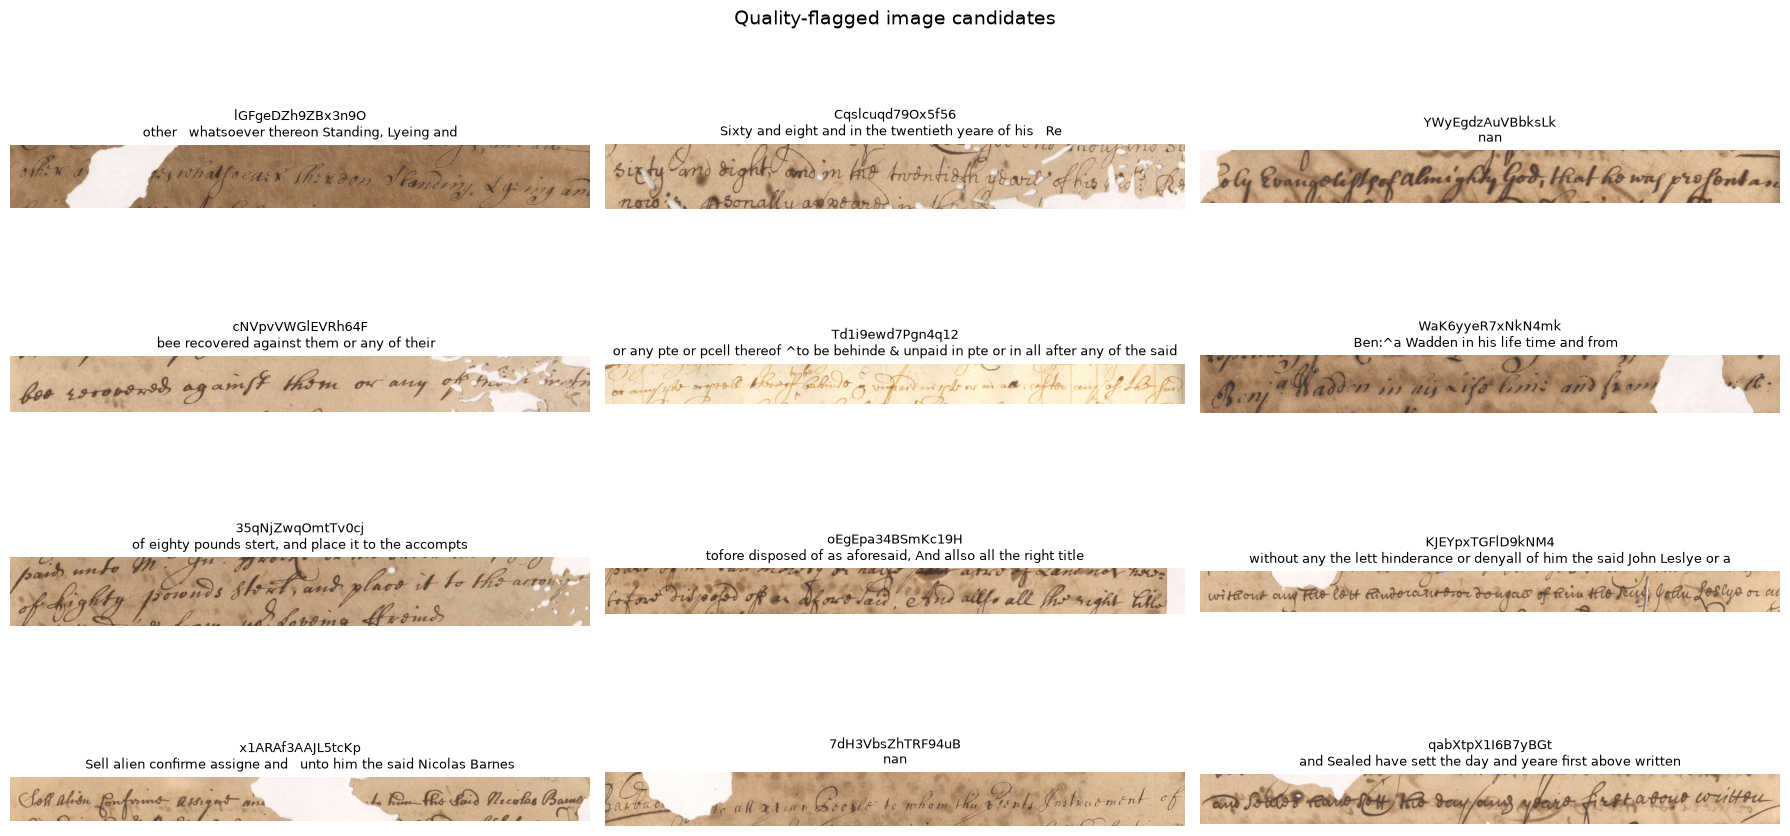

In [22]:
# Visualize likely blank / low-quality images.
quality_for_display = quality.merge(train[[ID_COL, TARGET_COL]], on=ID_COL, how="left")
candidate_df = quality_for_display[quality_for_display["quality_flag_count"].gt(0)].head(30)
show_image_grid(candidate_df, title="Quality-flagged image candidates", n=12, cols=3)

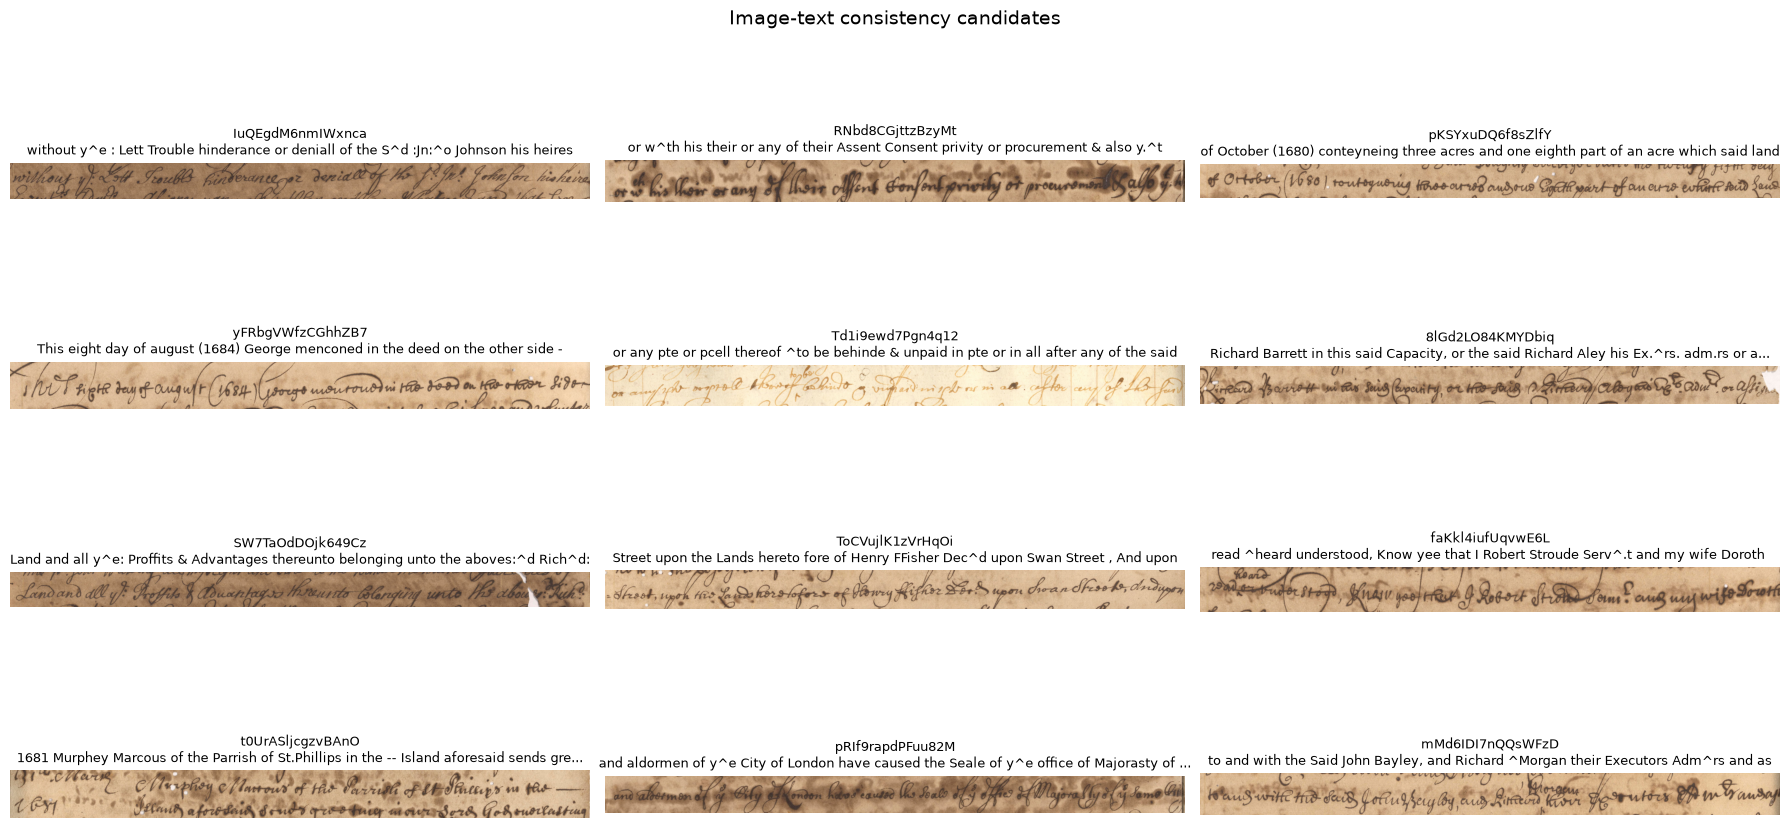

In [23]:
# Visualize likely image-text mismatch candidates.
consistency_for_display = consistency.merge(train[[ID_COL, TARGET_COL]], on=ID_COL, how="left", suffixes=("", "_raw"))
if TARGET_COL not in consistency_for_display.columns and f"{TARGET_COL}_raw" in consistency_for_display.columns:
    consistency_for_display[TARGET_COL] = consistency_for_display[f"{TARGET_COL}_raw"]
candidate_df = consistency_for_display[consistency_for_display["consistency_flag_count"].gt(0)].head(30)
show_image_grid(candidate_df, title="Image-text consistency candidates", n=12, cols=3)

In [24]:
# Visualize exact duplicate image groups with conflicting labels, if any.
if len(exact_summary) and (exact_summary["unique_labels"] > 1).any():
    conflict_hashes = exact_summary.loc[exact_summary["unique_labels"].gt(1), "file_md5"].head(3).tolist()
    candidate_df = train_quality[train_quality["file_md5"].isin(conflict_hashes)].merge(train[[ID_COL, TARGET_COL]], on=ID_COL, how="left")
    show_image_grid(candidate_df, title="Exact duplicate images with conflicting labels", n=12, cols=3)
else:
    print("No exact duplicate image groups with conflicting labels found.")

No exact duplicate image groups with conflicting labels found.


## 9. Manual Review Table

This combines label, image-quality, and image-text consistency flags into one candidate table. Sort by `total_flag_count` for manual review.

In [25]:
manual_review = train[[ID_COL, TARGET_COL]].copy()
manual_review = manual_review.merge(label_flags[[ID_COL, "label_flag_count", *flag_cols]], on=ID_COL, how="left")
manual_review = manual_review.merge(
    quality[quality["split"].eq("train")][[ID_COL, "quality_flag_count", *quality_flag_cols]],
    on=ID_COL,
    how="left",
)
manual_review = manual_review.merge(
    consistency[[ID_COL, "consistency_flag_count", *consistency_flag_cols]],
    on=ID_COL,
    how="left",
)
count_cols = ["label_flag_count", "quality_flag_count", "consistency_flag_count"]
manual_review[count_cols] = manual_review[count_cols].fillna(0).astype(int)
manual_review["total_flag_count"] = manual_review[count_cols].sum(axis=1)
manual_review = manual_review.sort_values("total_flag_count", ascending=False)
manual_review.to_csv(REPORT_DIR / "manual_review_candidates.csv", index=False)
print(f"Saved: {REPORT_DIR / 'manual_review_candidates.csv'}")
print(manual_review["total_flag_count"].value_counts().sort_index().to_string())
manual_review[manual_review["total_flag_count"].gt(0)].head(100)

Saved: /home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/reports/data_integrity/manual_review_candidates.csv
total_flag_count
0       1
1      28
2    2894
3    1061
4     108
5       5
6       1


,ID,Target,label_flag_count,flag_empty,flag_whitespace,flag_control,flag_non_ascii,flag_very_short,flag_very_long,flag_low_alpha,flag_repeated_chars,flag_repeated_punctuation,quality_flag_count,flag_almost_blank,flag_too_dark,flag_too_bright_low_foreground,flag_low_dynamic_range,flag_low_sharpness,flag_top_or_bottom_crop,flag_left_or_right_crop,consistency_flag_count,flag_width_text_mismatch,flag_shape_text_residual,flag_short_label_wide_image,flag_long_label_narrow_image,total_flag_count
1258,t0UrASljcgzvBAnO,1681 Murphey Marcous of the Parrish of St.Phillips in the -- Island aforesaid sends greeting in our Lord God everlasting,2,False,False,False,False,False,True,False,False,True,2,False,False,False,False,False,True,True,2,True,True,False,False,6
775,s2MsNg2IwhtVDwB8,as aforesaid and the said william Martin,2,False,True,False,False,True,False,False,False,False,2,False,False,False,False,False,True,True,1,True,False,False,False,5
1102,GBuYg6OqB1AZdYYg,This day being the 3^d. of August. 167,2,False,True,False,False,True,False,False,False,False,2,False,False,False,False,False,True,True,1,True,False,False,False,5
3831,FaZXVwKpNADcg50S,and every part thereof to him the said,2,False,True,False,False,True,False,False,False,False,2,False,False,False,False,False,True,True,1,True,False,False,False,5
2704,WaK6yyeR7xNkN4mk,Ben:^a Wadden in his life time and from,2,False,True,False,False,True,False,False,False,False,2,False,False,False,False,False,True,True,1,True,False,False,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,aqTw9otCG3kCDQiu,or Meant mentioned or Intended to be Granted & Conveyed unto the s^.d Benj,1,False,True,False,False,False,False,False,False,False,2,False,False,False,False,False,True,True,1,True,False,False,False,4
731,yKZgZHtxrrg3RZLI,"owne use and uses benefitt , and aduantage And it is h",1,False,True,False,False,False,False,False,False,False,2,False,False,False,False,False,True,True,1,True,False,False,False,4
747,pG6SDBl3f6w5ETFZ,W^m Olivant W^m Booke Dennis Cornelius,2,False,True,False,False,True,False,False,False,False,2,False,False,False,False,False,True,True,0,False,False,False,False,4
45,W84Lw7FYVOL8tFrx,age portion to and with the Said Elizabeth Vaughan Now in -,1,False,True,False,False,False,False,False,False,False,2,False,False,False,False,False,True,True,1,True,False,False,False,4


## 10. Summary Checklist

After running the notebook, inspect these files in `reports/data_integrity/`:

- `image_quality_audit.csv`
- `exact_duplicate_image_groups.csv`
- `near_duplicate_ahash_groups.csv`
- `label_integrity_audit.csv`
- `character_frequency.csv`
- `suspicious_label_candidates.csv`
- `suspicious_image_quality_candidates.csv`
- `image_numeric_anomaly_candidates.csv`
- `text_numeric_anomaly_candidates.csv`
- `image_text_consistency_candidates.csv`
- `manual_review_candidates.csv`

Recommended next action: manually inspect top candidates before removing or correcting anything. For this competition, false positives are likely, so do not automatically drop rows based only on these flags.